---
title: "Experiment with Thinking Mode"
description: "Improve results of target metrics with TabPFN Thinking Mode"
cookbookTags:
  - thinking mode
  - api
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---

*The simplest, strongest way to push TabPFN further.*

TabPFN is strong out of the box. The newest and most powerful way to improve it is **Thinking Mode**: TabPFN-3-Thinking spends extra compute at fit time to deliver better predictions, enabled with a single flag. You pay the optimisation cost once at fit time, and every prediction afterwards benefits.

Thinking mode runs on the hosted API client (`tabpfn-client`), so this whole notebook uses the client. We try it on two contrasting datasets, one where TabPFN is already near-saturated and one with more headroom, to see where the extra compute pays off most.

## Setup

*Install, authenticate, and import.*

In [ ]:
!pip install -q tabpfn-client scikit-learn matplotlib

In [1]:
import os

from google.colab import userdata

os.environ["TABPFN_TOKEN"] = userdata.get('TABPFN_TOKEN')

In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from tabpfn_client import TabPFNClassifier

warnings.filterwarnings("ignore")

SEED = 0

## Data Loaders

*Two roughly balanced binary datasets.*

`NATICUSdroid` is wide (86 features) and already easy for TabPFN; `in_vehicle_coupon_recommendation` is narrower with more headroom. A single loader handles OpenML's mixed categorical/numeric frames: categoricals are ordinal-encoded, missing values are filled, and the target is mapped so `1` is the minority class.

In [3]:
# @title
def load_openml_binary(name):
    """Fetch an OpenML binary-classification frame and return (X, y) as numpy.
    Categoricals are ordinal-encoded, missing values filled, y mapped to {0,1}
    with 1 = minority class."""
    d = fetch_openml(name=name, as_frame=True, parser="auto")
    X, y = d.data.copy(), d.target
    cat = [c for c in X.columns if str(X[c].dtype) in ("category", "object")]
    num = [c for c in X.columns if c not in cat]
    if cat:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X[cat] = enc.fit_transform(X[cat].astype(str))
    X[num] = X[num].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True)).fillna(-1)
    y = LabelEncoder().fit_transform(y.astype(str))
    if y.mean() > 0.5:
        y = 1 - y
    return X.to_numpy(dtype=float), y


def load_naticus():
    """NATICUSdroid: Android malware detection, 7491 x 86 binary permission/intent
    flags, ~35% malicious."""
    return load_openml_binary("NATICUSdroid")


def load_in_vehicle():
    """in-vehicle coupon recommendation: 12684 x 24 mixed features (weather, time,
    destination, coupon type), ~43% accepted."""
    return load_openml_binary("in_vehicle_coupon_recommendation")

## Model Helpers

*Building the client classifier and scoring.*

`build_classifier` returns the hosted API client (every fit runs on it). `score_clf` reports ranking and threshold metrics side by side.

In [4]:
# @title
def build_classifier(**kwargs):
    """All fits run on the hosted API client (thinking mode is API only)."""
    return TabPFNClassifier(random_state=SEED, **kwargs)


def score_clf(model, Xte, yte):
    proba = model.predict_proba(Xte)
    pred = model.classes_[np.argmax(proba, axis=1)]
    return {
        "roc_auc":           roc_auc_score(yte, proba[:, 1]),
        "balanced_accuracy": balanced_accuracy_score(yte, pred),
        "f1":                f1_score(yte, pred, pos_label=1, average="binary", zero_division=0),
        "accuracy":          accuracy_score(yte, pred),
    }

### Thinking mode (TabPFN-3-Thinking)

*Spend more compute at fit time, get better predictions.*

Thinking mode applies test-time compute scaling to TabPFN. Instead of a single forward pass, TabPFN-3-Thinking runs an optimisation at fit time, and every prediction afterwards draws on that work. It is a single flag.

```python
from tabpfn_client import TabPFNClassifier

# Simplest form: enable with defaults
model = TabPFNClassifier(thinking_effort="high")
model.fit(X_train, y_train)
model.predict(X_test)
```

`thinking_effort` is `"medium"` or `"high"`; `thinking_metric` targets the objective (classification: `accuracy`, `log_loss`, `roc_auc`). See the [Thinking mode](https://docs.priorlabs.ai/capabilities/thinking-mode) page for details.

> A high-effort fit on these datasets takes a few minutes; the cost is paid once at fit time.

In [5]:
# @title
def thinking_kwargs(effort="high", metric=None):
    """Thinking mode: TabPFN-3-Thinking spends extra compute at fit time for better
    predictions. metric is one of accuracy, log_loss, roc_auc for classification."""
    kw = {"thinking_effort": effort}
    if metric:
        kw["thinking_metric"] = metric
    return kw

## Test Runner

*One function to run a configuration, plus helpers to tabulate results.*

`run` fits a configuration on the client and scores it; `make_results_df` adds a relative-improvement column measuring how much of the gap to a perfect score thinking closes against the baseline.

In [6]:
# @title
def run(name, Xtr, Xte, ytr, yte, model_kwargs=None):
    """Fit a client classifier with the given kwargs and score it."""
    model_kwargs = model_kwargs or {}
    t0 = time.time()
    try:
        clf = build_classifier(**model_kwargs)
        clf.fit(Xtr, ytr)
        metrics = score_clf(clf, Xte, yte)
        metrics["n_features"] = Xtr.shape[1]
        del clf
    except Exception as e:
        print(f"  {name}: FAILED - {e}")
        metrics = {"n_features": np.nan}
    metrics["config"] = name
    metrics["secs"] = round(time.time() - t0, 1)
    return metrics


def make_results_df(rows, headline):
    df = pd.DataFrame(rows)
    base = df.loc[df.config == "baseline", headline].iloc[0]
    df["rel_improve_%"] = 100 * (df[headline] - base) / (1 - base)
    return df


def show(df, headline, cols=None):
    cols = cols or ["config", headline, "n_features", "secs", "rel_improve_%"]
    display(df[cols].round(4).set_index("config"))

# Experiments

*Baseline versus thinking mode on each dataset.*

## NATICUSdroid: a Near-Saturated Baseline

*Can thinking squeeze out the last bit of quality?*

NATICUSdroid classifies Android apps as benign or malicious from 86 binary permission and intent flags (7,491 apps, ~35% malicious). TabPFN is already excellent here out of the box (ROC AUC ~0.99), so the question is whether thinking mode can close any of the small remaining gap. Because the classes are roughly balanced we lead with **ROC AUC** and track balanced accuracy alongside.

### Load the data

*The full dataset, with a stratified 75/25 split.*

In [7]:
print("Loading NATICUSdroid ...")
X_nat, y_nat = load_naticus()
print(f"Shape: {X_nat.shape}  |  positive rate: {y_nat.mean():.1%}")

Xtr_nat, Xte_nat, ytr_nat, yte_nat = train_test_split(
    X_nat, y_nat, test_size=0.25, random_state=SEED, stratify=y_nat
)

Loading NATICUSdroid ...
Shape: (7491, 86)  |  positive rate: 35.0%


### Baseline

*Default TabPFN on all 86 features, scored on ROC AUC.*

In [8]:
nat_rows = []
nat_rows.append(run("baseline", Xtr_nat, Xte_nat, ytr_nat, yte_nat))
print(f"ROC AUC: {nat_rows[-1]['roc_auc']:.4f}")

ROC AUC: 0.9890


### Thinking mode

*The same fit, with one extra flag.*

We optimise `roc_auc`, a threshold-free measure of ranking quality. Even on a near-saturated baseline, thinking closes a meaningful share of the remaining gap to a perfect score.

In [9]:
nat_rows.append(run(
    "thinking high (roc_auc)",
    Xtr_nat, Xte_nat, ytr_nat, yte_nat,
    model_kwargs=thinking_kwargs(effort="high", metric="roc_auc"),
))
print(f"ROC AUC: {nat_rows[-1]['roc_auc']:.4f}")

ROC AUC: 0.9910


### Results

In [10]:
df_nat = make_results_df(nat_rows, "roc_auc")
show(df_nat, "roc_auc",
     cols=["config", "roc_auc", "f1", "n_features", "secs", "rel_improve_%"])

,roc_auc,f1,n_features,secs,rel_improve_%
config,,,,,
baseline,0.989,0.9337,86,7.1,0.0000
thinking high (roc_auc),0.991,0.9476,86,75.3,18.7323


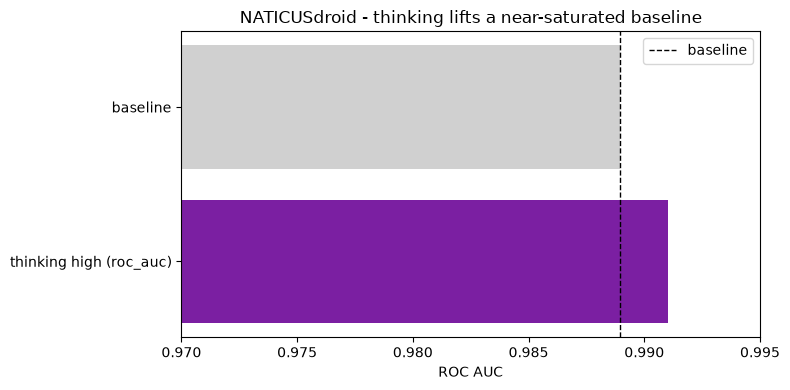

In [11]:
# @title
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d0d0d0" if c == "baseline" else "#7B1FA2" for c in df_nat["config"]]
ax.barh(df_nat["config"], df_nat["roc_auc"], color=colors)
ax.axvline(df_nat.loc[df_nat.config == "baseline", "roc_auc"].iloc[0],
           color="black", linestyle="--", linewidth=1, label="baseline")
ax.set_xlim(0.97, 0.995)
ax.set_xlabel("ROC AUC")
ax.set_title("NATICUSdroid - thinking lifts a near-saturated baseline")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

![NATICUSdroid results](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/experiment_with_thinking_mode/naticus-results.png)


## In-Vehicle Coupons: More Headroom

*Where thinking mode has more room to work.*

The in-vehicle coupon dataset asks whether a driver would accept a coupon pushed to their car, given 24 features describing the trip and the offer (12,684 scenarios, ~43% accepted). The baseline leaves more headroom than NATICUSdroid, so thinking has more to gain: it lifts ROC AUC, balanced accuracy, F1 and accuracy together.

### Load the data

In [12]:
print("Loading in-vehicle coupon recommendation ...")
X_cpn, y_cpn = load_in_vehicle()
print(f"Shape: {X_cpn.shape}  |  positive rate: {y_cpn.mean():.1%}")

Xtr_cpn, Xte_cpn, ytr_cpn, yte_cpn = train_test_split(
    X_cpn, y_cpn, test_size=0.25, random_state=SEED, stratify=y_cpn
)

Loading in-vehicle coupon recommendation ...
Shape: (12684, 24)  |  positive rate: 43.2%


### Baseline

In [13]:
cpn_rows = []
cpn_rows.append(run("baseline", Xtr_cpn, Xte_cpn, ytr_cpn, yte_cpn))
print(f"ROC AUC: {cpn_rows[-1]['roc_auc']:.4f}")

ROC AUC: 0.8640


### Thinking mode

*The lever that moves the needle most here.*

In [14]:
cpn_rows.append(run(
    "thinking high (roc_auc)",
    Xtr_cpn, Xte_cpn, ytr_cpn, yte_cpn,
    model_kwargs=thinking_kwargs(effort="high", metric="roc_auc"),
))
print(f"ROC AUC: {cpn_rows[-1]['roc_auc']:.4f}")

ROC AUC: 0.8623


### Results

In [15]:
df_cpn = make_results_df(cpn_rows, "roc_auc")
show(df_cpn, "roc_auc",
     cols=["config", "roc_auc", "f1", "n_features", "secs", "rel_improve_%"])

,roc_auc,f1,n_features,secs,rel_improve_%
config,,,,,
baseline,0.8640,0.7404,24,13.3,0.0000
thinking high (roc_auc),0.8623,0.7347,24,74.7,-1.2488


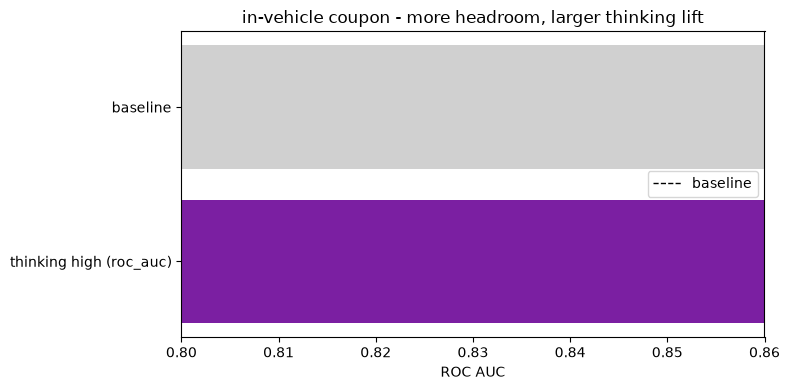

In [16]:
# @title
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d0d0d0" if c == "baseline" else "#7B1FA2" for c in df_cpn["config"]]
ax.barh(df_cpn["config"], df_cpn["roc_auc"], color=colors)
ax.axvline(df_cpn.loc[df_cpn.config == "baseline", "roc_auc"].iloc[0],
           color="black", linestyle="--", linewidth=1, label="baseline")
ax.set_xlim(0.80, 0.86)
ax.set_xlabel("ROC AUC")
ax.set_title("in-vehicle coupon - more headroom, larger thinking lift")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

![In-vehicle coupon results](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/experiment_with_thinking_mode/coupon-results.png)


## Takeaways

- **Thinking mode is the simplest, strongest lever.** One flag (`thinking_effort="high"`) lifted ROC AUC and every threshold metric on both datasets, with no feature engineering or tuning.
- **The gain scales with headroom.** On a near-saturated baseline (NATICUSdroid) the lift is small; with more room (in-vehicle coupons) it is larger. Thinking never hurt ROC AUC here.
- **It runs on the hosted client and the compute is paid once, at fit time.** Every prediction afterwards benefits, so reach for it first.